# Обучение основной модели CatBoost и сравнение с baseline

В данном ноутбуке выполняется обучение основной модели прогнозирования качества сна на основе алгоритма CatBoost, расчёт метрик качества и сравнительный анализ с базовой моделью логистической регрессии.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.append(str(Path("..").resolve()))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier, Pool

from src.config import MODEL_DATA_PATH, RANDOM_STATE

## Загрузка и предобработка

In [2]:
model_df = pd.read_csv(MODEL_DATA_PATH)

print(model_df.shape)
model_df.head()

(47523, 82)


,SEQN,calendar_date,weekday,dayofweek,window_number,night_number,month,day,dayofyear,target_bad_sleep,...,dur_spt_sleep_min_lag3,dur_spt_wake_IN_min_lag3,dur_spt_wake_LIG_min_lag3,dur_spt_wake_MOD_min_lag3,dur_spt_wake_VIG_min_lag3,dur_day_min_lag3,dur_spt_min_lag3,dur_day_spt_min_lag3,ACC_spt_sleep_mg_lag3,excluded_lag3
0,62161,2000-01-12,Wednesday,4,4,5,1,12,12,1,...,436.0,39.0,2.0,0.0,0.0,876.0,477.0,1353.0,6.743,0.0
1,62161,2000-01-13,Thursday,5,5,6,1,13,13,1,...,403.0,92.0,1.0,0.0,0.0,942.0,496.0,1438.0,3.550,0.0
2,62161,2000-01-14,Friday,6,6,7,1,14,14,1,...,435.0,101.0,10.0,0.0,0.0,896.0,546.0,1442.0,3.243,0.0
3,62161,2000-01-15,Saturday,7,7,8,1,15,15,1,...,425.0,108.0,5.0,0.0,0.0,902.0,538.0,1440.0,5.848,0.0
4,62163,2000-01-12,Wednesday,4,4,5,1,12,12,0,...,332.0,43.0,3.0,0.0,0.0,1004.0,378.0,1382.0,11.669,0.0


In [5]:
target_col = "target_bad_sleep"
group_col = "SEQN"

X = model_df.drop(columns=[target_col])
y = model_df[target_col].astype(int)
groups = model_df[group_col]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

drop_cols = ["SEQN", "calendar_date"]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

print("Уникальных участников в train:", groups_train.nunique())
print("Уникальных участников в test :", groups_test.nunique())
print("Пересечение участников:", len(set(groups_train).intersection(set(groups_test))))

Train: (37976, 79) (37976,)
Test : (9547, 79) (9547,)
Уникальных участников в train: 10430
Уникальных участников в test : 2608
Пересечение участников: 0


In [6]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric count:", len(numeric_cols))

Categorical: ['weekday']
Numeric count: 78


In [8]:
cat_features = [X_train.columns.get_loc(col) for col in categorical_cols]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

## Обучение основной модели

In [9]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=100
)

cat_model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True
)

0:	test: 0.7174443	best: 0.7174443 (0)	total: 192ms	remaining: 1m 35s
100:	test: 0.7446270	best: 0.7446270 (100)	total: 3.3s	remaining: 13s
200:	test: 0.7459298	best: 0.7459800 (199)	total: 6.37s	remaining: 9.47s
300:	test: 0.7451359	best: 0.7460672 (252)	total: 9.45s	remaining: 6.24s
400:	test: 0.7451863	best: 0.7460672 (252)	total: 12.8s	remaining: 3.15s
499:	test: 0.7443662	best: 0.7460672 (252)	total: 16s	remaining: 0us

bestTest = 0.7460671818
bestIteration = 252

Shrink model to first 253 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

## Предсказания и метрики

In [10]:
y_pred = cat_model.predict(test_pool)
y_pred = y_pred.astype(int)

y_proba = cat_model.predict_proba(test_pool)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ROC-AUC :", round(roc_auc, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

ROC-AUC : 0.7461
Precision: 0.6557
Recall   : 0.4657
F1-score : 0.5446


In [11]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7356    0.8587    0.7924      6051
           1     0.6557    0.4657    0.5446      3496

    accuracy                         0.7148      9547
   macro avg     0.6956    0.6622    0.6685      9547
weighted avg     0.7063    0.7148    0.7016      9547



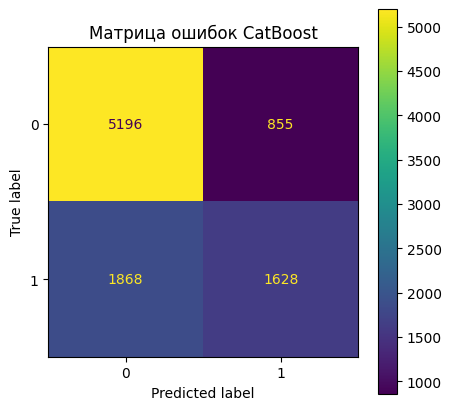

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax)
plt.title("Матрица ошибок CatBoost")
plt.show()

## Важность признаков

In [13]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
7,sleep_efficiency_lag1,14.078878
31,sleep_efficiency_lag2,13.270499
55,sleep_efficiency_lag3,13.083151
22,dur_spt_wake_IN_min_lag1,3.907584
2,window_number,2.760119
51,dur_spt_min_lag2,2.354756
69,dur_spt_sleep_min_lag3,2.239605
46,dur_spt_wake_IN_min_lag2,1.512993
45,dur_spt_sleep_min_lag2,1.463917
27,dur_spt_min_lag1,1.348698


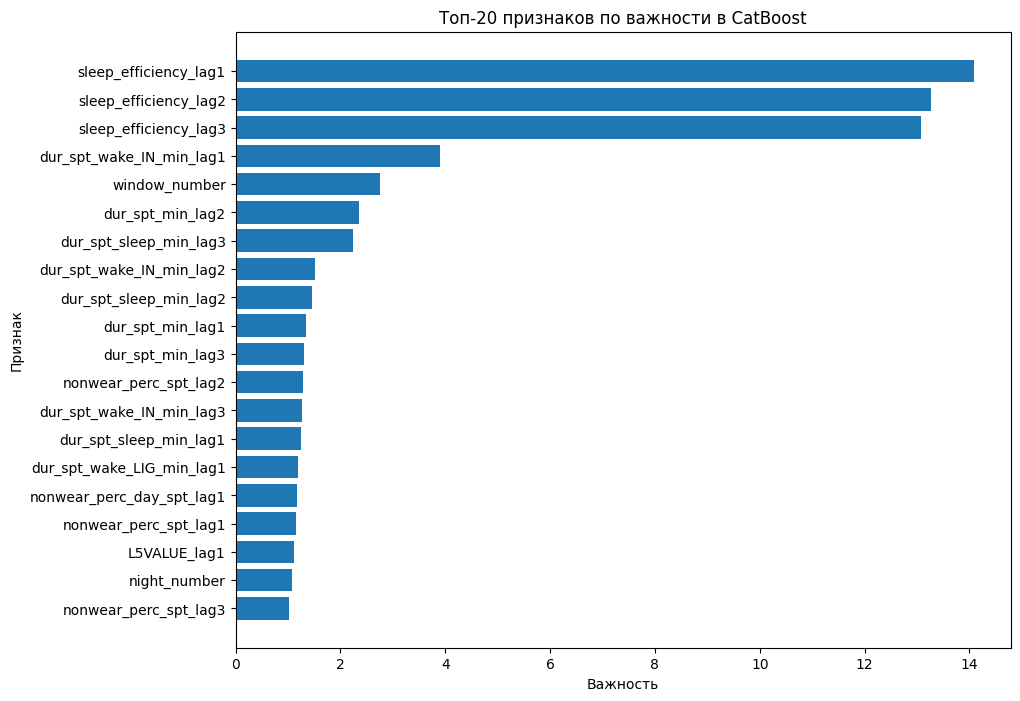

In [14]:
top_n = 20
fi_top = feature_importance.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.title("Топ-20 признаков по важности в CatBoost")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.show()

In [16]:
comparison_df = pd.DataFrame({
    "model": ["LogisticRegression", "CatBoost"],
    "roc_auc": [0.7408, roc_auc],
    "precision": [0.5727, precision],
    "recall": [0.6264, recall],
    "f1_score": [0.5984, f1]
})

comparison_df = comparison_df.round(4)
comparison_df

,model,roc_auc,precision,recall,f1_score
0,LogisticRegression,0.7408,0.5727,0.6264,0.5984
1,CatBoost,0.7461,0.6557,0.4657,0.5446


In [17]:
comparison_df.to_csv("../reports/model_comparison.csv", index=False)
feature_importance.to_csv("../reports/catboost_feature_importance.csv", index=False)

## Пробуем разные пороги для классификации

In [19]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

rows = []

for thr in thresholds:
    y_thr = (y_proba >= thr).astype(int)
    
    rows.append({
        "threshold": thr,
        "precision": precision_score(y_test, y_thr),
        "recall": recall_score(y_test, y_thr),
        "f1": f1_score(y_test, y_thr)
    })

threshold_df = pd.DataFrame(rows)
threshold_df.round(4)

,threshold,precision,recall,f1
0,0.30,0.5144,0.7640,0.6149
1,0.35,0.5509,0.6894,0.6124
2,0.40,0.5821,0.6176,0.5993
3,0.45,0.6211,0.5398,0.5776
4,0.50,0.6557,0.4657,0.5446
5,0.55,0.6882,0.3933,0.5005
6,0.60,0.7203,0.3212,0.4443
7,0.65,0.7433,0.2451,0.3687
8,0.70,0.7909,0.1894,0.3056
9,0.75,0.8144,0.1230,0.2137


In [20]:
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_row

threshold    0.300000
precision    0.514445
recall       0.764016
f1           0.614871
Name: 0, dtype: float64

In [21]:
best_threshold = best_row["threshold"]

y_pred_best = (y_proba >= best_threshold).astype(int)

print("Best threshold:", best_threshold)
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 4))
print("Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Recall   :", round(recall_score(y_test, y_pred_best), 4))
print("F1-score :", round(f1_score(y_test, y_pred_best), 4))
print(classification_report(y_test, y_pred_best, digits=4))

Best threshold: 0.3
ROC-AUC : 0.7461
Precision: 0.5144
Recall   : 0.764
F1-score : 0.6149
              precision    recall  f1-score   support

           0     0.8106    0.5834    0.6785      6051
           1     0.5144    0.7640    0.6149      3496

    accuracy                         0.6495      9547
   macro avg     0.6625    0.6737    0.6467      9547
weighted avg     0.7021    0.6495    0.6552      9547



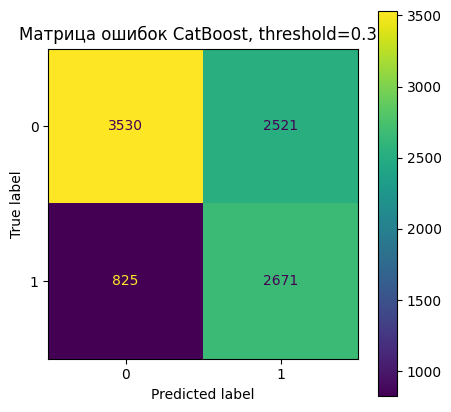

In [22]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax)
plt.title(f"Матрица ошибок CatBoost, threshold={best_threshold:.2f}")
plt.show()